In [1]:
#Imports and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import joblib
import os
import json
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, matthews_corrcoef,
    confusion_matrix, classification_report
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

pd.set_option("display.float_format", lambda x: "%.6f" % x)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("../../data/loan_default/loan_engineered.csv")
print("Shape      :", df.shape)
print("Defaults   :", f"{df['is_default'].sum():,}")
print("Default %  :", round(df["is_default"].mean() * 100, 2))
print("Features   :", df.shape[1] - 1)

Shape      : (2257159, 43)
Defaults   : 294,860
Default %  : 13.06
Features   : 42


In [2]:
# Train Test Split
print("TEMPORAL TRAIN-TEST SPLIT")
print()

split_idx = int(len(df) * 0.8)
df_train = df.iloc[:split_idx].copy()
df_test = df.iloc[split_idx:].copy()

feature_cols = [c for c in df.columns if c != "is_default"]
X_train = df_train[feature_cols]
y_train = df_train["is_default"]
X_test = df_test[feature_cols]
y_test = df_test["is_default"]

print(f"Train size    : {len(df_train):,} | Defaults: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Test size     : {len(df_test):,} | Defaults: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")
print()

scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

print("Applying SMOTE on training data only...")
smote = SMOTE(sampling_strategy=0.3, random_state=42, k_neighbors=5, n_jobs=-1)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print(f"After SMOTE — Non-default: {(y_train_res==0).sum():,} | Default: {(y_train_res==1).sum():,}")

os.makedirs("../../models/loan_default", exist_ok=True)
joblib.dump(scaler, "../../models/loan_default/robust_scaler.pkl")
joblib.dump(feature_cols, "../../models/loan_default/feature_names.pkl")
print("Scaler saved.")

TEMPORAL TRAIN-TEST SPLIT

Train size    : 1,805,727 | Defaults: 231,421 (12.82%)
Test size     : 451,432 | Defaults: 63,439 (14.05%)

Applying SMOTE on training data only...
After SMOTE — Non-default: 1,574,306 | Default: 472,291
Scaler saved.


In [4]:
# Business Cost Matrix
COST_FALSE_NEGATIVE = 15000
COST_FALSE_POSITIVE = 500
REWARD_TRUE_POSITIVE = 8000
REWARD_TRUE_NEGATIVE = 0

print("LOAN DEFAULT BUSINESS COST MATRIX")
print()
print(f"False Negative (missed default)  : -${COST_FALSE_NEGATIVE:,}  (bank loses full loan amount)")
print(f"False Positive (rejected good)   : -${COST_FALSE_POSITIVE:,}   (lost interest income)")
print(f"True Positive (caught default)   : +${REWARD_TRUE_POSITIVE:,}  (avoided loss)")
print(f"True Negative (approved good)    :  ${REWARD_TRUE_NEGATIVE}     (normal business)")

def business_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cost = (tp * REWARD_TRUE_POSITIVE) + (fn * -COST_FALSE_NEGATIVE) + (fp * -COST_FALSE_POSITIVE)
    return cost, tn, fp, fn, tp

def optimal_threshold(y_true, y_prob):
    best_t, best_cost = 0.5, -np.inf
    for t in np.arange(0.01, 0.99, 0.005):
        y_pred = (y_prob >= t).astype(int)
        if y_pred.sum() == 0:
            continue
        cost, *_ = business_cost(y_true, y_pred)
        if cost > best_cost:
            best_cost = cost
            best_t = t
    return best_t, best_cost

def evaluate(name, y_true, y_prob):
    threshold, _ = optimal_threshold(y_true, y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    cost, tn, fp, fn, tp = business_cost(y_true, y_pred)
    result = {
        "name": name, "threshold": round(float(threshold), 4),
        "auc_roc": round(float(roc_auc_score(y_true, y_prob)), 6),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 6),
        "f1": round(float(f1_score(y_true, y_pred)), 6),
        "precision": round(float(precision_score(y_true, y_pred)), 6),
        "recall": round(float(recall_score(y_true, y_pred)), 6),
        "mcc": round(float(matthews_corrcoef(y_true, y_pred)), 6),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "business_value": int(cost), "y_prob": y_prob
    }
    print(f"Model          : {name}")
    print(f"Threshold      : {threshold:.4f}")
    print(f"AUC-ROC        : {result['auc_roc']}")
    print(f"Avg Precision  : {result['avg_precision']}")
    print(f"F1             : {result['f1']}")
    print(f"Recall         : {result['recall']}")
    print(f"Precision      : {result['precision']}")
    print(f"MCC            : {result['mcc']}")
    print(f"Caught Default : {tp} | Missed: {fn} | False Alarms: {fp}")
    print(f"Business Value : ${cost:,}")
    print()
    return result

print("Cost matrix and evaluation functions ready.")

LOAN DEFAULT BUSINESS COST MATRIX

False Negative (missed default)  : -$15,000  (bank loses full loan amount)
False Positive (rejected good)   : -$500   (lost interest income)
True Positive (caught default)   : +$8,000  (avoided loss)
True Negative (approved good)    :  $0     (normal business)
Cost matrix and evaluation functions ready.


In [5]:
# Train XGBoost
print("TRAINING XGBOOST")
print()

scale_pos = int((y_train_res == 0).sum() / (y_train_res == 1).sum())

xgb_params = {
    "n_estimators": 500,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 10,
    "gamma": 1,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "scale_pos_weight": scale_pos,
    "eval_metric": "aucpr",
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_cv = XGBClassifier(**xgb_params)
cv_scores = cross_val_score(xgb_cv, X_train_res, y_train_res, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"CV AUC-ROC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

xgb_model = XGBClassifier(**xgb_params)
xgb_model.fit(X_train_res, y_train_res, eval_set=[(X_test_scaled, y_test)], verbose=False)
joblib.dump(xgb_model, "../../models/loan_default/xgb_model.pkl")
print("XGBoost trained and saved.")
print()

xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]
xgb_results = evaluate("XGBoost", y_test, xgb_prob)

TRAINING XGBOOST

CV AUC-ROC: 0.8706 (+/- 0.0005)
XGBoost trained and saved.

Model          : XGBoost
Threshold      : 0.0550
AUC-ROC        : 0.686189
Avg Precision  : 0.259148
F1             : 0.250657
Recall         : 0.997793
Precision      : 0.143332
MCC            : 0.054132
Caught Default : 63299 | Missed: 140 | False Alarms: 378327
Business Value : $315,128,500



In [6]:
# Train LightGBM
print("TRAINING LIGHTGBM")
print()

lgbm_params = {
    "n_estimators": 500,
    "max_depth": 6,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_samples": 50,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1
}

lgbm_cv = LGBMClassifier(**lgbm_params)
cv_scores_lgbm = cross_val_score(lgbm_cv, X_train_res, y_train_res, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"CV AUC-ROC: {cv_scores_lgbm.mean():.4f} (+/- {cv_scores_lgbm.std():.4f})")

lgbm_model = LGBMClassifier(**lgbm_params)
lgbm_model.fit(X_train_res, y_train_res)
joblib.dump(lgbm_model, "../../models/loan_default/lgbm_model.pkl")
print("LightGBM trained and saved.")
print()

lgbm_prob = lgbm_model.predict_proba(X_test_scaled)[:, 1]
lgbm_results = evaluate("LightGBM", y_test, lgbm_prob)

TRAINING LIGHTGBM

CV AUC-ROC: 0.8723 (+/- 0.0006)
LightGBM trained and saved.

Model          : LightGBM
Threshold      : 0.0750
AUC-ROC        : 0.686364
Avg Precision  : 0.258846
F1             : 0.252477
Recall         : 0.996422
Precision      : 0.144552
MCC            : 0.064397
Caught Default : 63212 | Missed: 227 | False Alarms: 374083
Business Value : $315,249,500



In [7]:
# Train Logistic Regression
print("TRAINING LOGISTIC REGRESSION (Baseline + Interpretability)")
print()

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    C=0.1
)

lr_cv = cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"CV AUC-ROC: {lr_cv.mean():.4f} (+/- {lr_cv.std():.4f})")

lr_model.fit(X_train_scaled, y_train)
joblib.dump(lr_model, "../../models/loan_default/lr_model.pkl")
print("Logistic Regression trained and saved.")
print()

lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_results = evaluate("LogisticRegression", y_test, lr_prob)

TRAINING LOGISTIC REGRESSION (Baseline + Interpretability)



/Users/pankurajasaivardhan/Documents/SENTINEL-ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pankurajasaivardhan/Documents/SENTINEL-ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pankurajasaivardhan/Documents/SENTINEL-ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pankurajasaivardhan/Documents/SENTINEL-ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pankurajasaivardhan/Documents/SENTINEL-ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200

CV AUC-ROC: 0.7051 (+/- 0.0009)


/Users/pankurajasaivardhan/Documents/SENTINEL-ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pankurajasaivardhan/Documents/SENTINEL-ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pankurajasaivardhan/Documents/SENTINEL-ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pankurajasaivardhan/Documents/SENTINEL-ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/pankurajasaivardhan/Documents/SENTINEL-ML/.venv/lib/python3.9/site-packages/sklearn/line

Logistic Regression trained and saved.

Model          : LogisticRegression
Threshold      : 0.0100
AUC-ROC        : 0.668777
Avg Precision  : 0.244779
F1             : 0.246426
Recall         : 0.999905
Precision      : 0.14053
MCC            : 0.000461
Caught Default : 63433 | Missed: 6 | False Alarms: 387951
Business Value : $313,398,500



MODEL COMPARISON

             Model  AUC-ROC  Avg Precision       F1   Recall  Precision  Caught  Missed  False Alarms  Business Value $
           XGBoost 0.686189       0.259148 0.250657 0.997793   0.143332   63299     140        378327         315128500
          LightGBM 0.686364       0.258846 0.252477 0.996422   0.144552   63212     227        374083         315249500
LogisticRegression 0.668777       0.244779 0.246426 0.999905   0.140530   63433       6        387951         313398500


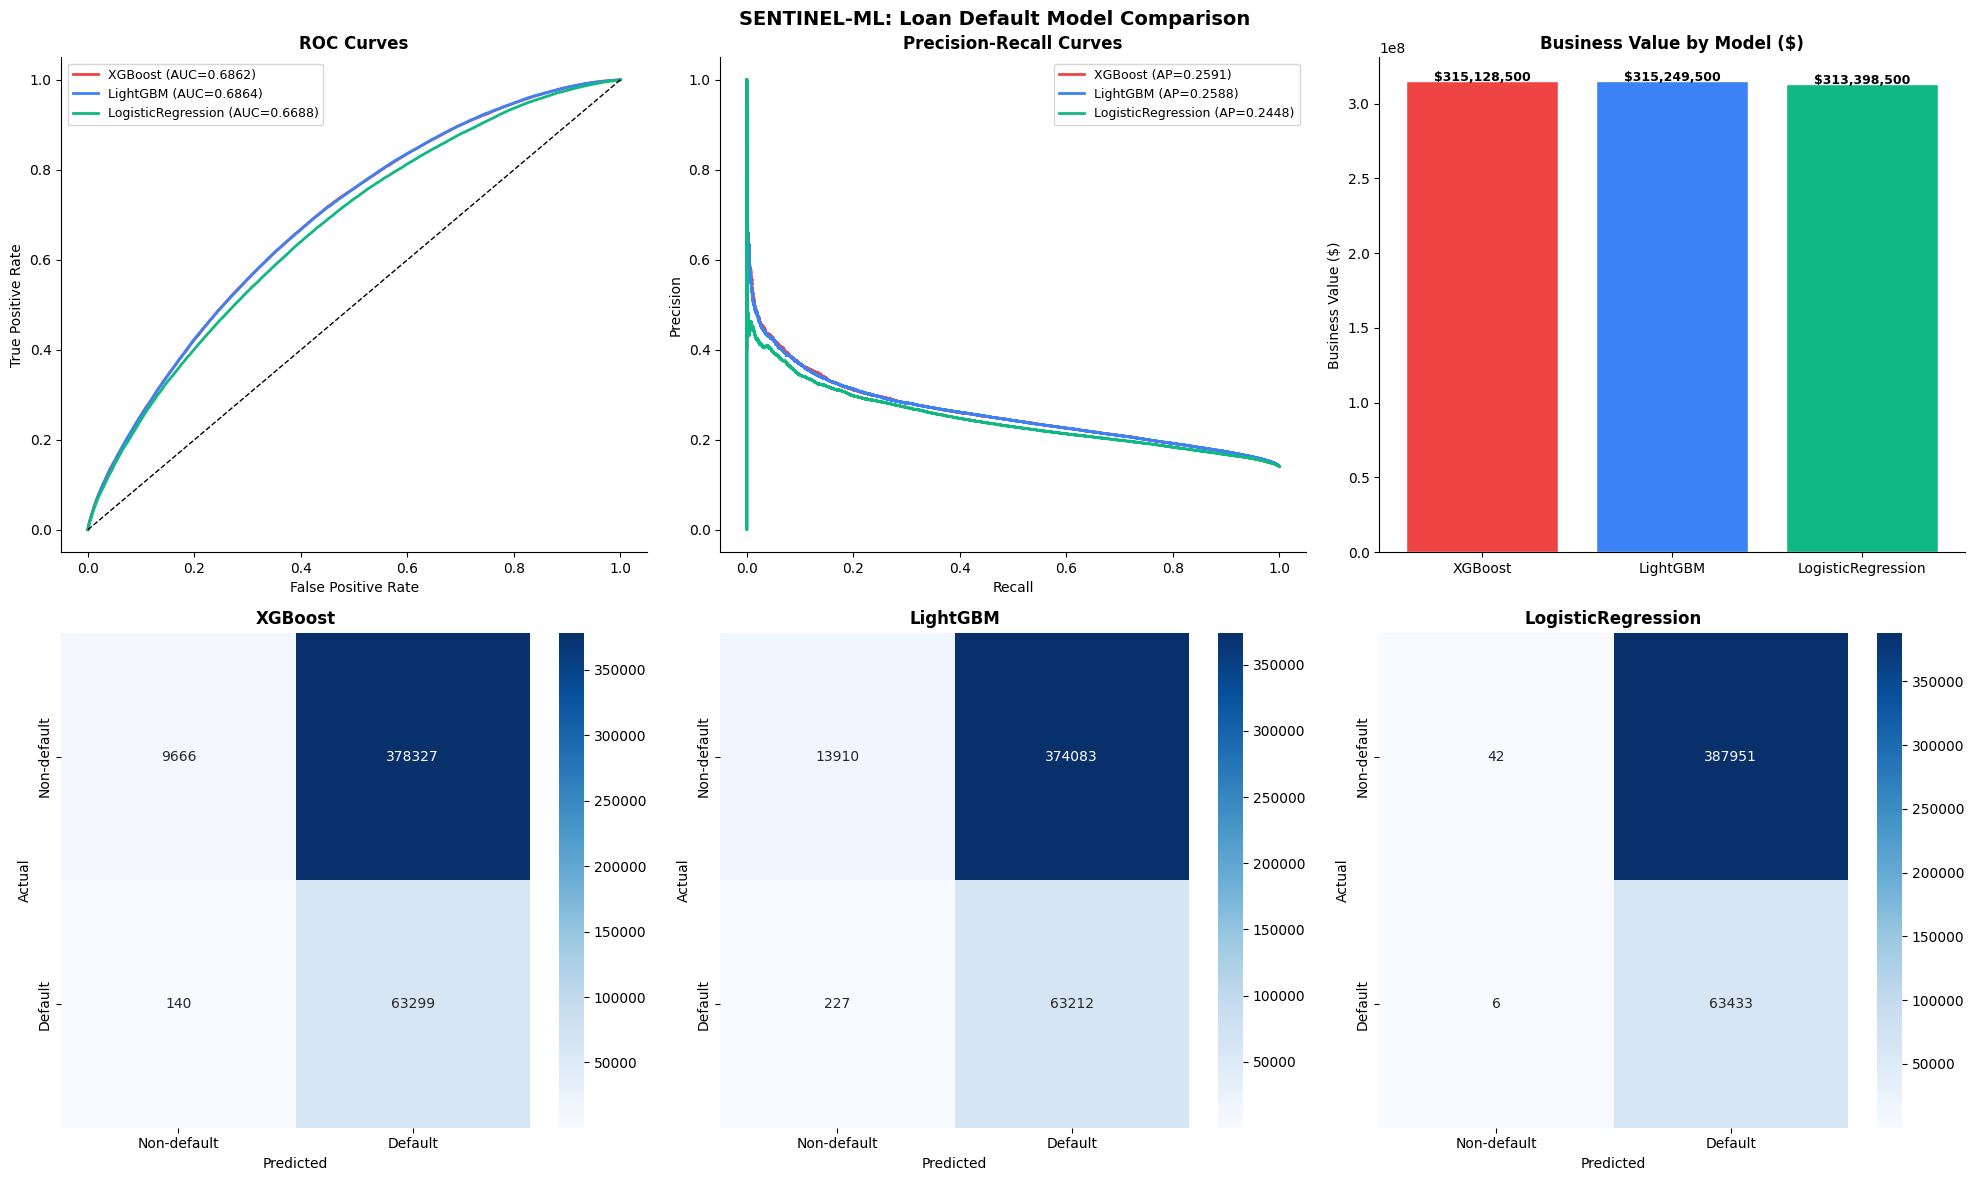

In [8]:
# Model Comparison and Plots
print("MODEL COMPARISON")
print()

results_list = [xgb_results, lgbm_results, lr_results]
comparison = pd.DataFrame([{
    "Model": r["name"],
    "AUC-ROC": r["auc_roc"],
    "Avg Precision": r["avg_precision"],
    "F1": r["f1"],
    "Recall": r["recall"],
    "Precision": r["precision"],
    "Caught": r["tp"],
    "Missed": r["fn"],
    "False Alarms": r["fp"],
    "Business Value $": r["business_value"]
} for r in results_list])
print(comparison.to_string(index=False))

from sklearn.metrics import roc_curve, precision_recall_curve

fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 3, figure=fig)
colors_map = {"XGBoost": "#ef4444", "LightGBM": "#3b82f6", "LogisticRegression": "#10b981"}

ax1 = fig.add_subplot(gs[0, 0])
for r in results_list:
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    ax1.plot(fpr, tpr, label=f"{r['name']} (AUC={r['auc_roc']:.4f})",
             color=colors_map[r["name"]], linewidth=2)
ax1.plot([0,1],[0,1],"k--", linewidth=1)
ax1.set_title("ROC Curves", fontweight="bold")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs[0, 1])
for r in results_list:
    p, rec, _ = precision_recall_curve(y_test, r["y_prob"])
    ax2.plot(rec, p, label=f"{r['name']} (AP={r['avg_precision']:.4f})",
             color=colors_map[r["name"]], linewidth=2)
ax2.set_title("Precision-Recall Curves", fontweight="bold")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend(fontsize=9)

ax3 = fig.add_subplot(gs[0, 2])
bv = [r["business_value"] for r in results_list]
names = [r["name"] for r in results_list]
bars = ax3.bar(names, bv, color=[colors_map[n] for n in names], edgecolor="white")
ax3.set_title("Business Value by Model ($)", fontweight="bold")
ax3.set_ylabel("Business Value ($)")
for bar, val in zip(bars, bv):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100000,
             f"${val:,}", ha="center", fontsize=9, fontweight="bold")

for i, r in enumerate(results_list):
    ax = fig.add_subplot(gs[1, i])
    cm = confusion_matrix(y_test, (r["y_prob"] >= r["threshold"]).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Non-default", "Default"],
                yticklabels=["Non-default", "Default"])
    ax.set_title(f"{r['name']}", fontweight="bold")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.suptitle("SENTINEL-ML: Loan Default Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/loan_default/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# SHAP and Save Best Model
print("SHAP EXPLAINABILITY")
print()

all_results = [xgb_results, lgbm_results, lr_results]
best = max(all_results, key=lambda x: x["auc_roc"])
print(f"Best model: {best['name']} | AUC={best['auc_roc']}")

best_model_obj = {"XGBoost": xgb_model, "LightGBM": lgbm_model, "LogisticRegression": lr_model}[best["name"]]

explainer = shap.TreeExplainer(best_model_obj) if best["name"] in ["XGBoost", "LightGBM"] else shap.LinearExplainer(best_model_obj, X_train_scaled.iloc[:1000])
X_sample = X_test_scaled.iloc[:500]
shap_values = explainer.shap_values(X_sample)
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

feature_importance_shap = pd.Series(np.abs(shap_vals).mean(axis=0), index=feature_cols).sort_values(ascending=False)
print("Top 10 features by SHAP:")
for i, (feat, val) in enumerate(feature_importance_shap.head(10).items(), 1):
    print(f"  {i:2}. {feat:<30} {val:.6f}")

joblib.dump(best_model_obj, "../../models/loan_default/best_model.pkl")

report = {
    "best_model": best["name"],
    "optimal_threshold": best["threshold"],
    "auc_roc": best["auc_roc"],
    "avg_precision": best["avg_precision"],
    "f1": best["f1"],
    "precision": best["precision"],
    "recall": best["recall"],
    "mcc": best["mcc"],
    "defaults_caught": best["tp"],
    "defaults_missed": best["fn"],
    "false_alarms": best["fp"],
    "business_value": best["business_value"],
    "test_size": int(len(y_test)),
    "test_defaults": int(y_test.sum()),
    "feature_count": len(feature_cols)
}

with open("../../models/loan_default/model_report.json", "w") as f:
    json.dump(report, f, indent=4)

print()
print(f"Best model saved to models/loan_default/best_model.pkl")
print(f"Report saved to models/loan_default/model_report.json")
print()


SHAP EXPLAINABILITY

Best model: LightGBM | AUC=0.686364
Top 10 features by SHAP:
   1. grade_encoded                  0.404279
   2. emp_length_clean               0.259979
   3. int_rate                       0.219710
   4. open_acc                       0.128882
   5. loan_to_income_ratio           0.112698
   6. fico_range_low                 0.100420
   7. home_encoded                   0.100245
   8. experienced_borrower           0.097851
   9. composite_risk_score           0.090390
  10. int_rate_normalized            0.071101

Best model saved to models/loan_default/best_model.pkl
Report saved to models/loan_default/model_report.json

